# 2.6 Resampling Methods

Data have natural variability. Any statistic we compute from a sample (a mean, a correlation, a regression slope) inherits that variability.

**Resampling methods** let us measure it. Broadly, resampling refers to any technique where we repeatedly draw observations from a sample, recompute a statistic on each draw, and study the distribution of results. Applications include hypothesis testing, uncertainty propagation, and confidence intervals.

The lesson has two levels. Level 1 walks through three basic resampling techniques: randomization, bootstrapping, and Monte Carlo. Level 2 applies the bootstrap to model inference for a linear regression, first on synthetic GNSS data with a known answer, then on real GNSS data from the Cascadia subduction zone.

First, import the modules we need:

In [1]:
import os
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mlgeo_synth

**A note on random numbers.** Older NumPy code seeds the global random state with `np.random.seed(42)` and then calls functions like `np.random.normal`. Modern NumPy replaces this with an explicit generator object: `rng = np.random.default_rng(42)`. The generator carries its own state, so different parts of a program (or a notebook) do not interfere with each other through a hidden global. We use the generator idiom throughout this book. Fixing the seed makes the notebook reproducible from top to bottom.

In [2]:
# One generator for the whole notebook, with a fixed seed for reproducibility.
rng = np.random.default_rng(42)
rng

Generator(PCG64) at 0x310023A00

## 1. Examples of resampling techniques (Level 1)

### 1.1 Randomization

Given two datasets, $A$ and $B$, and a parameter, $x$, we can randomly reassign observations to either $A$ or $B$, calculate some statistic (e.g., $x_A - x_B$), and repeat to build a distribution of that statistic under the null hypothesis that group labels do not matter.

In [3]:
# We begin with two datasets, A and B
A = rng.normal(5, 2.5, 100)
B = rng.normal(5.5, 2.5, 100)

# We then calculate the means of each dataset
mean_A = np.mean(A)
mean_B = np.mean(B)

print(f'The means of A and B are {mean_A:.3f} and {mean_B:.3f}, respectively.')

# And, for the sake of illustration, also calculate the difference between these means
diff_means = mean_A - mean_B
print(f'The difference of means is {diff_means:.3f}.')

The means of A and B are 4.874 and 5.473, respectively.
The difference of means is -0.599.


Now, we resample.

In [4]:
# First, how many times do we want to resample?
number_runs = 10000

# Next, we create an array that will store the difference of means
array_of_diffs = np.zeros(number_runs)

# To ease computational burden, declare some variables:
# a combined list of A and B, and the length of A
combined = np.concatenate((A, B))
length_A = len(A)

For each run, we shuffle the combined data, split it into two new groups of the original sizes, and recalculate the difference of means.

In [5]:
for i in range(number_runs):
    # Shuffle the combined list. Note that shuffle works in place!
    rng.shuffle(combined)
    # Split the list into A and B, maintaining their original sizes.
    new_A = combined[0:length_A]
    new_B = combined[length_A:len(combined)]
    # Calculate and store a difference of means
    array_of_diffs[i] = np.mean(new_A) - np.mean(new_B)

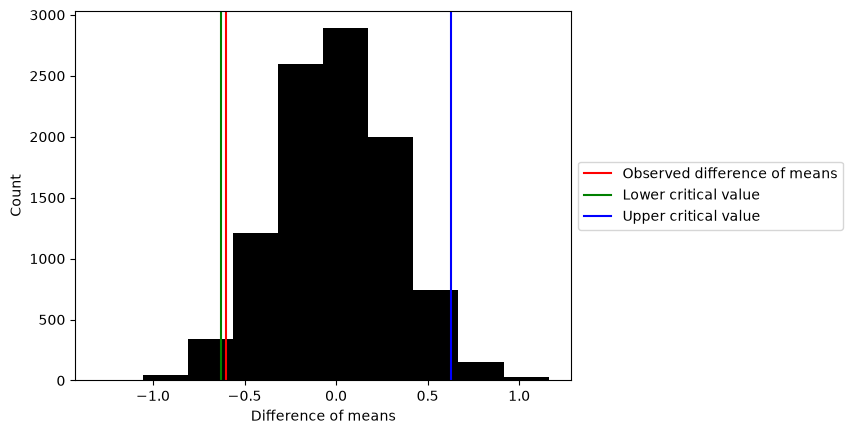

In [6]:
# Plot the array of diffs
plt.hist(array_of_diffs, color='black')

# Given an alpha of 0.05, can we accept or reject the null hypothesis of no difference in means?
alpha = 0.05
lower_critical_value = np.quantile(array_of_diffs, alpha / 2)
upper_critical_value = np.quantile(array_of_diffs, 1 - (alpha / 2))

# Plot the critical values and the observed value
plt.axvline(x=diff_means, color='r')
plt.axvline(x=lower_critical_value, color='g')
plt.axvline(x=upper_critical_value, color='b')
plt.xlabel('Difference of means')
plt.ylabel('Count')
plt.legend(['Observed difference of means', 'Lower critical value', 'Upper critical value'],
           loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### 1.2 Bootstrapping

When bootstrapping, you repeatedly draw observations, **with replacement**, from a sample. Each bootstrap resample has the **same size as the original sample**. Because you draw with replacement, a resample will contain duplicate observations and omit others. The spread of the statistic across resamples estimates the sampling uncertainty of that statistic.

Bootstrapping does not make strong assumptions about the underlying distribution of the data.

We first create a synthetic "true population" of correlated data using the generator method ``multivariate_normal`` ([docs here](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.multivariate_normal.html)). The mean of both variables is zero and their covariance is -0.75.

In [7]:
# A population where two variables are strongly anticorrelated
correlated_data = rng.multivariate_normal([0, 0], [[1, -0.75], [-0.75, 1]], 1000)

Check that the data is indeed anticorrelated by plotting one variable against the other.

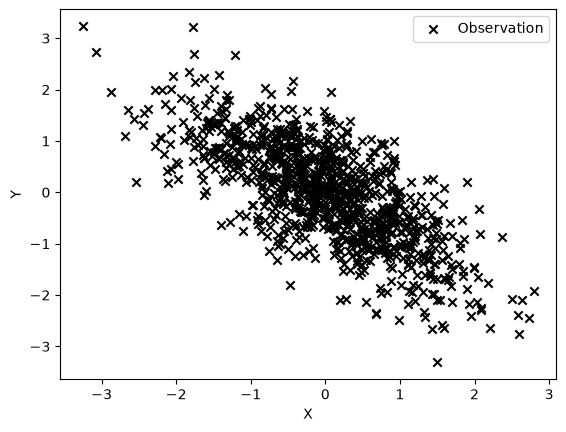

In [8]:
plt.scatter(correlated_data[:, 0], correlated_data[:, 1], marker='x', c='black')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(['Observation'])
plt.show()

We verify that the Pearson [correlation coefficient](https://en.wikipedia.org/wiki/Correlation_coefficient) is close to our target using the numpy function ``corrcoef``.

In [9]:
correlation_matrix = np.corrcoef(correlated_data[:, 0], correlated_data[:, 1])
print(f'The population correlation coefficient is {correlation_matrix[0, 1]:.3f}.')

The population correlation coefficient is -0.721.


In practice we never observe the full population. We now take a small subset of the data --- think of the subset as *the sample we actually collected*.

The correlation coefficient of our sample is -0.619.


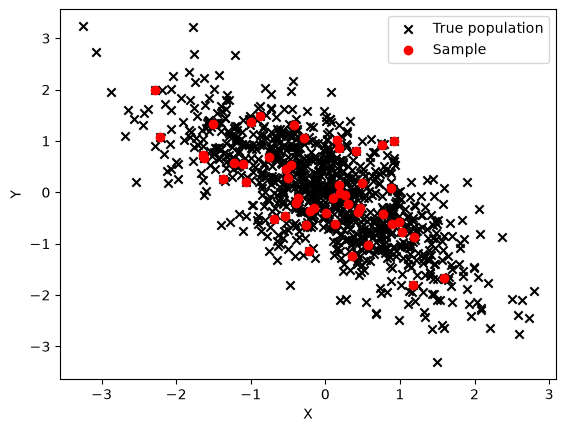

In [10]:
nsubset = 50
subset = rng.choice(correlated_data, size=nsubset, replace=False)

# Report the correlation coefficient of the sample
sample_corr = np.corrcoef(subset[:, 0], subset[:, 1])[0, 1]
print(f'The correlation coefficient of our sample is {sample_corr:.3f}.')

# Plot both the population and our sample
plt.scatter(correlated_data[:, 0], correlated_data[:, 1], marker='x', c='black')
plt.scatter(subset[:, 0], subset[:, 1], c='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(['True population', 'Sample'])
plt.show()

Now we bootstrap. Each resample draws `len(subset)` pairs **from the sample itself**, with replacement. The resample size matches the original sample size: that is what makes the spread of the resampled statistic mimic the sampling variability of the original estimate.

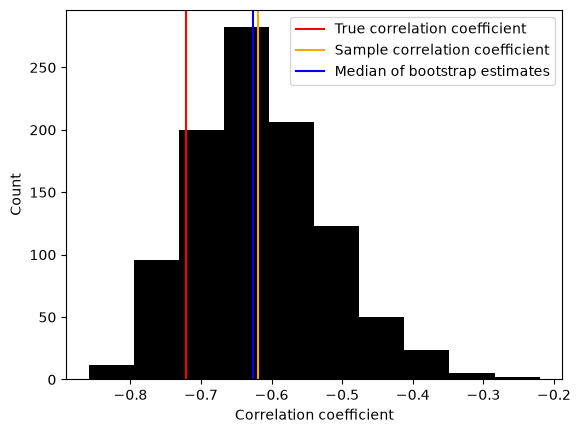

In [11]:
number_runs = 1000

# Array to record the correlation coefficient of each resample
corr_coef_collector = np.zeros(number_runs)

# The bootstrap resample size equals the original sample size.
length_sub = len(subset)

for i in range(number_runs):
    # Draw length_sub pairs from the sample, WITH REPLACEMENT
    new_pairs = rng.choice(subset, size=length_sub, replace=True)
    corr_coef_collector[i] = np.corrcoef(new_pairs[:, 0], new_pairs[:, 1])[0, 1]

# Plot the bootstrap distribution
plt.hist(corr_coef_collector, color='black')
plt.xlabel('Correlation coefficient')
plt.ylabel('Count')

plt.axvline(x=correlation_matrix[0, 1], color='red')
plt.axvline(x=sample_corr, color='orange')
plt.axvline(x=np.median(corr_coef_collector), color='blue')
plt.legend(['True correlation coefficient', 'Sample correlation coefficient',
            'Median of bootstrap estimates'])
plt.show()

The median of the bootstrap estimates sits near the *sample* correlation coefficient, not the true population value. The bootstrap cannot fix the bias of a small sample; it quantifies the uncertainty around the estimate you have.

What happens if you increase the size of the original sample?

#### What if the resample size differs from the sample size?

The bootstrap is defined with resample size equal to the sample size. As an experiment, we deliberately break that rule and vary the resample size. Watch the spread of the bootstrap distribution.

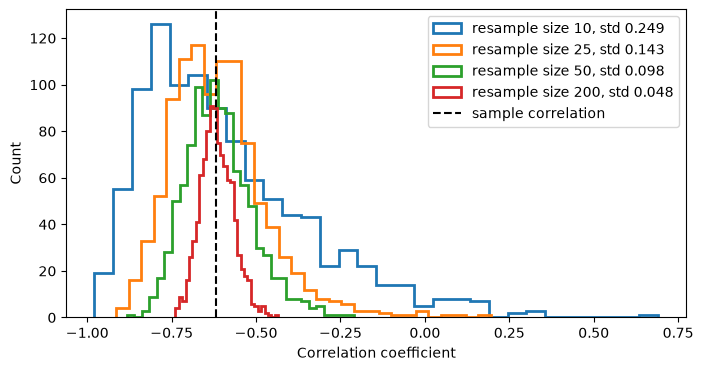

In [12]:
resample_sizes = [10, 25, 50, 200]  # 50 is the actual sample size

fig, ax = plt.subplots(figsize=(8, 4))
for m in resample_sizes:
    stats_m = np.zeros(number_runs)
    for i in range(number_runs):
        new_pairs = rng.choice(subset, size=m, replace=True)
        stats_m[i] = np.corrcoef(new_pairs[:, 0], new_pairs[:, 1])[0, 1]
    ax.hist(stats_m, bins=30, histtype='step', lw=2,
            label=f'resample size {m}, std {np.std(stats_m):.3f}')

ax.axvline(sample_corr, color='k', ls='--', label='sample correlation')
ax.set_xlabel('Correlation coefficient')
ax.set_ylabel('Count')
ax.legend()
plt.show()

Smaller resamples produce a wider spread of the statistic: a correlation estimated from 10 pairs is noisier than one estimated from 50. Resamples larger than the sample produce a spread that is too narrow, which understates the true uncertainty. Only a resample size equal to the original sample size reproduces the sampling variability of the estimate you actually made.

### 1.3 Monte Carlo

Named after the casino in Monaco, Monte Carlo methods involve *simulating new data* based on a known (or assumed!) statistical model. Unlike the previous two examples, we do not take draws from an existing sample.

Monte Carlo techniques have many applications: probabilistic risk assessment, uncertainty propagation in models, and evaluation of systems too complicated for closed-form analysis.

Here, we demonstrate Monte Carlo sampling by estimating $\pi$.

We begin with a central conceit: the ratio of the area of a circle to the area of its bounding square is $\pi/4$.

We then imagine a circle of radius 1 inscribed within a square with sides going from -1 to 1.

In [13]:
# We draw (x, y) points from a *uniform* distribution and determine whether each point
# sits within the circle. Every point lands in the square; only some land in the circle.
in_circle = np.empty([0, 2])
in_square = np.empty([0, 2])

# Generate the samples. Keep the number small at first.
number_runs = 50

for _ in range(number_runs):  # note that _ avoids creating a loop variable we never use
    x = rng.uniform(low=-1, high=1)
    y = rng.uniform(low=-1, high=1)
    # How far is this point from the origin?
    origin_dist = x**2 + y**2
    # If origin_dist is less than 1, the point is inside the circle
    if origin_dist <= 1:
        in_circle = np.append(in_circle, [[x, y]], axis=0)
    in_square = np.append(in_square, [[x, y]], axis=0)

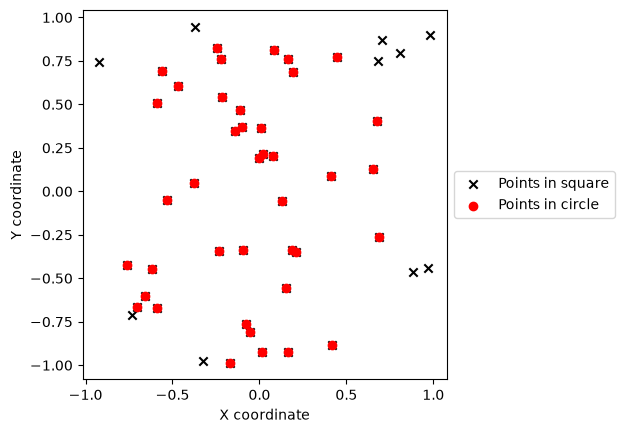

In [14]:
# Visualize what we just did
plt.scatter(in_square[:, 0], in_square[:, 1], marker='x', c='black')
plt.scatter(in_circle[:, 0], in_circle[:, 1], marker='o', c='red')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.legend(['Points in square', 'Points in circle'], loc='center left', bbox_to_anchor=(1, 0.5))
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.show()

We now estimate $\pi$ using the counts of points in the circle and in the square as approximations to their areas.

In [15]:
pi_est = 4 * (len(in_circle) / len(in_square))
print(f'We estimate the value of pi to be: {pi_est}.')

We estimate the value of pi to be: 3.2.


With a few runs, we do not get a good answer.

A Monte Carlo approach needs more runs to **converge**.

Explore how changing the number of runs changes your estimate of $\pi$ (and how your calculation converges).

## 2. Using resampling for robust model inference (Level 2)

The plan: fit a linear trend to GNSS position data and use the bootstrap to put an uncertainty on the slope (the plate velocity). We start with a **synthetic** series, where we know the true velocity, so we can compare the bootstrap distribution against the right answer. Then we repeat the analysis on **real** data from station P395 in the Pacific Northwest.

### 2.1 Synthetic GNSS series with a known velocity

The helper `mlgeo_synth.gnss_series` builds a synthetic daily GNSS displacement series with a known ground truth: a linear trend, seasonal cycles, and realistic noise (white, flicker, and random walk). We set the true velocity to 12 mm/yr.

In [16]:
true_velocity = 12.0  # mm/yr, our ground truth

gnss = mlgeo_synth.gnss_series(n_years=10, velocity_mm_yr=true_velocity, seed=42)
gnss.head()

,date,disp_mm,trend_mm,seasonal_mm,eq_mm
0,2015-01-01,-2.651412,0.000000,-2.591412,0.0
1,2015-01-02,-3.522117,0.032854,-2.615349,0.0
2,2015-01-03,-3.734687,0.065708,-2.638816,0.0
3,2015-01-04,-5.674045,0.098563,-2.661778,0.0
4,2015-01-05,-3.430546,0.131417,-2.684198,0.0


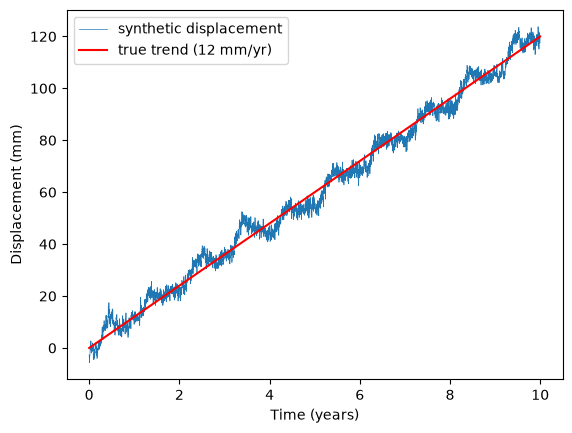

In [17]:
# Time in years since the first sample
t_syn = (gnss['date'] - gnss['date'].iloc[0]).dt.days / 365.25
d_syn = gnss['disp_mm']

plt.plot(t_syn, d_syn, lw=0.5, label='synthetic displacement')
plt.plot(t_syn, gnss['trend_mm'], 'r', label='true trend (12 mm/yr)')
plt.xlabel('Time (years)')
plt.ylabel('Displacement (mm)')
plt.legend()
plt.show()

Fit a straight line with `scipy.stats.linregress`. The slope is our velocity estimate.

In [18]:
from scipy import stats

fit = stats.linregress(t_syn, d_syn)
print(f'Estimated velocity: {fit.slope:.3f} mm/yr (true value: {true_velocity} mm/yr)')

Estimated velocity: 11.838 mm/yr (true value: 12.0 mm/yr)


The point estimate is close to the truth, but how confident should we be? Bootstrap: resample the (time, displacement) pairs with replacement --- resample size equal to the data length --- refit the line each time, and collect the slopes.

Bootstrap mean velocity: 11.838 mm/yr, standard deviation: 0.019 mm/yr


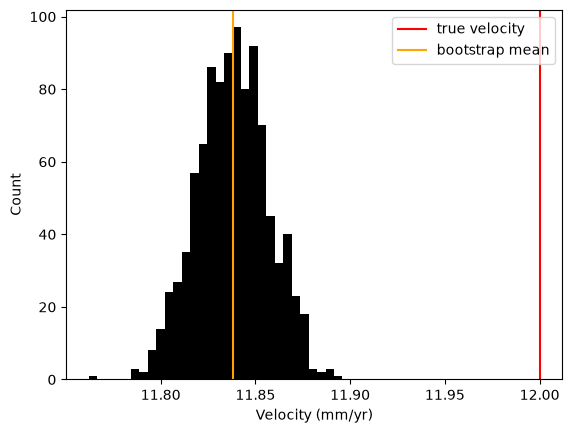

In [19]:
k = 1000
n_syn = len(t_syn)
t_arr = t_syn.to_numpy()
d_arr = d_syn.to_numpy()

vel_syn = np.zeros(k)
for j in range(k):
    ii = rng.integers(0, n_syn, size=n_syn)  # indices drawn with replacement
    vel_syn[j] = stats.linregress(t_arr[ii], d_arr[ii]).slope

print(f'Bootstrap mean velocity: {np.mean(vel_syn):.3f} mm/yr, '
      f'standard deviation: {np.std(vel_syn):.3f} mm/yr')

plt.hist(vel_syn, bins=30, color='black')
plt.axvline(true_velocity, color='red', label='true velocity')
plt.axvline(np.mean(vel_syn), color='orange', label='bootstrap mean')
plt.xlabel('Velocity (mm/yr)')
plt.ylabel('Count')
plt.legend()
plt.show()

Two things to notice.

First, the bootstrap distribution is centered on the *estimated* slope, not on the truth. The bootstrap quantifies the variability of the estimator; it cannot remove the offset between the estimate and the true velocity that this particular noise realization produced.

Second, the distribution is very narrow --- and the true velocity sits several bootstrap standard deviations away from its center. The error bar is too small. The reason: resampling pairs treats the residuals as independent, but GNSS noise is time-correlated (flicker and random walk). The pair bootstrap therefore *understates* the true uncertainty. More advanced schemes (block bootstrap) resample contiguous chunks of the series to preserve the correlation. Having the ground truth is what exposed this: with real data alone, the tight histogram would have looked reassuring.

### 2.2 Plate motion from real geodetic data

Now the real thing. We use a GNSS time series from station P395 in the Pacific Northwest and estimate the long-term motion due to the Cascadia subduction zone.

We download the time series from the University of Nevada, Reno [data center](http://geodesy.unr.edu/NGLStationPages/gpsnetmap/GPSNetMap.html). The `tenv3` file is whitespace-delimited with one header line. The columns we need are the decimal year (`yyyy.yyyy`) and the east, north, and up positions in meters (`__east(m)`, `_north(m)`, `____up(m)`).

In [20]:
sta = "P395"
url = f"https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/{sta}.tenv3"
print(url)

os.makedirs('data', exist_ok=True)
fname = f'data/{sta}.tenv3'
r = requests.get(url, timeout=60)
r.raise_for_status()
with open(fname, 'wb') as f:
    f.write(r.content)

# Whitespace-delimited file; the first line is the header.
df = pd.read_csv(fname, sep=r'\s+')
df.head()

https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/IGS20/P395.tenv3


,site,YYMMMDD,yyyy.yyyy,__MJD,week,d,reflon,_e0(m),__east(m),____n0(m),...,_ant(m),sig_e(m),sig_n(m),sig_u(m),__corr_en,__corr_eu,__corr_nu,_latitude(deg),_longitude(deg),__height(m)
0,P395,06JAN25,2006.0671,53760,1359,3,-123.9,3347,0.560065,4987420,...,0.0083,0.000748,0.001125,0.003637,-0.053526,0.039949,-0.344025,45.022279,-123.857527,53.03951
1,P395,06JAN26,2006.0698,53761,1359,4,-123.9,3347,0.560733,4987420,...,0.0083,0.000740,0.001135,0.003557,-0.030311,0.021842,-0.308583,45.022279,-123.857527,53.03502
2,P395,06JAN27,2006.0726,53762,1359,5,-123.9,3347,0.560999,4987420,...,0.0083,0.000735,0.001120,0.003583,-0.023363,0.042888,-0.330909,45.022279,-123.857527,53.04103
3,P395,06JAN28,2006.0753,53763,1359,6,-123.9,3347,0.560352,4987420,...,0.0083,0.000756,0.001132,0.003778,-0.024996,0.024686,-0.365856,45.022279,-123.857527,53.04785
4,P395,06JAN29,2006.0780,53764,1360,0,-123.9,3347,0.560269,4987420,...,0.0083,0.000738,0.001132,0.003582,-0.041592,0.058166,-0.318254,45.022279,-123.857527,53.03961


In [21]:
# Keep only the columns we need and give them simpler names.
df = df[['yyyy.yyyy', '__east(m)', '_north(m)', '____up(m)']].rename(
    columns={'yyyy.yyyy': 'decimal year',
             '__east(m)': 'delta e (m)',
             '_north(m)': 'delta n (m)',
             '____up(m)': 'delta v (m)'})

# Drop rows with missing values. dropna returns a new frame: assign the result.
df = df.dropna()
df.head()

,decimal year,delta e (m),delta n (m),delta v (m)
0,2006.0671,0.560065,0.310612,0.039514
1,2006.0698,0.560733,0.309070,0.035025
2,2006.0726,0.560999,0.311102,0.041026
3,2006.0753,0.560352,0.308281,0.047853
4,2006.0780,0.560269,0.310305,0.039609


In [22]:
# Reference each component to the first epoch so positions start at zero.
df['new delta e (m)'] = df['delta e (m)'] - df['delta e (m)'].values[0]
df['new delta n (m)'] = df['delta n (m)'] - df['delta n (m)'].values[0]
df['new delta v (m)'] = df['delta v (m)'] - df['delta v (m)'].values[0]
df.head()

,decimal year,delta e (m),delta n (m),delta v (m),new delta e (m),new delta n (m),new delta v (m)
0,2006.0671,0.560065,0.310612,0.039514,0.000000,0.000000,0.000000
1,2006.0698,0.560733,0.309070,0.035025,0.000668,-0.001542,-0.004489
2,2006.0726,0.560999,0.311102,0.041026,0.000934,0.000490,0.001512
3,2006.0753,0.560352,0.308281,0.047853,0.000287,-0.002331,0.008339
4,2006.0780,0.560269,0.310305,0.039609,0.000204,-0.000307,0.000095


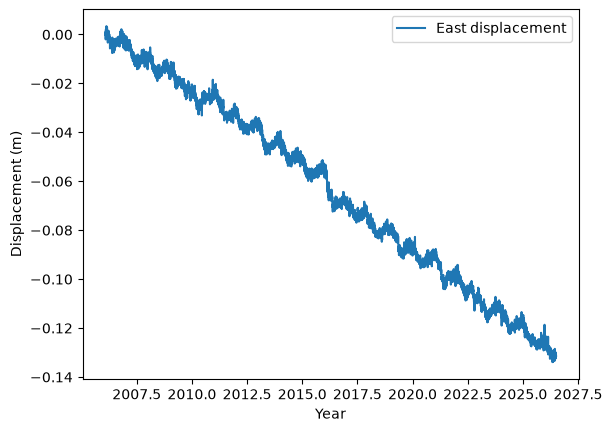

In [23]:
plt.plot(df['decimal year'], df['new delta e (m)'], label='East displacement')
plt.xlabel('Year')
plt.ylabel('Displacement (m)')
plt.legend()
plt.show()

### 2.3 Linear regression

There is a clean **linear trend** in the horizontal position data. We can fit the data using:

$E(t) = V_e t + u_e,$\
$N(t) = V_n t + u_n,$

where $t$ is time. We regress the data to find the coefficients $V_e$, $u_e$, $V_n$, $u_n$. The displacements are mostly westward, so we focus on the East component $E(t)$ for this exercise. The coefficients $u_e$ and $u_n$ are the intercepts at $t=0$. They are not zero here because $t$ starts in 2006. The coefficients $V_e$ and $V_n$ have the dimension of velocities:

$V_e \sim E(t) / t$, $V_n \sim N(t) / t$,

so this example lets us discuss a simple **linear regression** and resampling. We use both a SciPy function and a scikit-learn function.

To measure fit performance, we measure how well the variance is reduced by fitting the data (scatter points) against the model. The variance is:

$\text{Var}(x) = 1/n \sum_{i=1}^n (x_i-\hat{x})^2$,

where $\hat{x}$ is the mean of $x$. When fitting the regression, we predict the values $x_{pred}$. The residuals are the differences between the data and the predicted values: $e = x - x_{pred}$. $R^2$ or <i>coefficient of determination</i> is:

$R^2 = 1 - \text{Var}(x-x_{pred}) /\text{Var}(x) = 1 - \text{Var}(e) /\text{Var}(x)$

The smaller the error, the "better" the fit (we will discuss later that a fit can be too good!), and the closer $R^2$ is to one.

In [24]:
# Linear regression: displacement = velocity * time + intercept, East component.
Ve, intercept, r_value, p_value, std_err = stats.linregress(df['decimal year'],
                                                            df['new delta e (m)'])
print(sta, "overall plate motion there", Ve, 'm/year')
print("parameters: correlation coefficient %4.2f, P-value %4.2f, standard error of the slope %g"
      % (r_value, p_value, std_err))

P395 overall plate motion there -0.006540884541421708 m/year
parameters: correlation coefficient -1.00, P-value 0.00, standard error of the slope 5.78311e-06


We can also use the ``scikit-learn`` package:

Coefficient / velocity eastward (m/year):  -0.00654088454142171


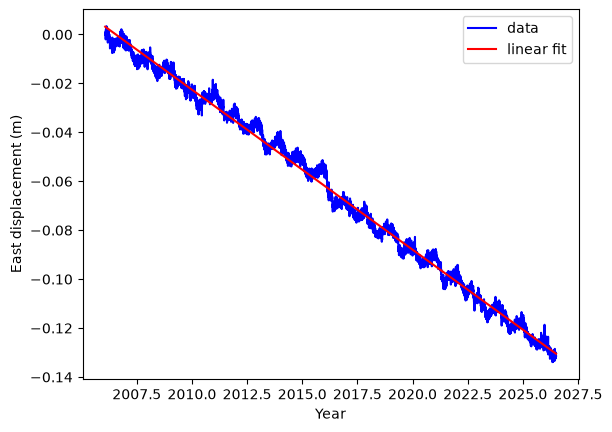

In [25]:
from sklearn.linear_model import LinearRegression

# Convert the data into numpy arrays. Reshaping to (n, 1) is required by scikit-learn.
E = np.asarray(df['new delta e (m)']).reshape(-1, 1)
t = np.asarray(df['decimal year']).reshape(-1, 1)

# Perform the linear regression on the entire available data
regr = LinearRegression()
regr.fit(t, E)
Epred = regr.predict(t)

# The coefficients
print('Coefficient / velocity eastward (m/year): ', regr.coef_[0][0])

# Plot the data and the fit
plt.plot(t, E, 'b', label='data')
plt.plot(t, Epred, 'r', label='linear fit')
plt.xlabel('Year')
plt.ylabel('East displacement (m)')
plt.legend()
plt.show()

To evaluate the errors of the model fit using ``sklearn``, we use the following functions:

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

# The mean squared error
print('Mean squared error (m^2): %.6f' % mean_squared_error(E, Epred))
# The coefficient of determination: 1 is the perfect prediction
print('Coefficient of determination: %.2f' % r2_score(E, Epred))

Mean squared error (m^2): 0.000009
Coefficient of determination: 0.99


### 2.4 Bootstrapping the velocity

Now we use bootstrapping to estimate the slope of the regression over many resampled datasets, exactly as we did for the synthetic series.

Scikit-learn provides ``resample`` in the ``utils`` module. Make sure you use ``replace=True`` and a resample size equal to the data length (the default). For reproducible results, you can pass a fixed ``random_state``. Bootstrapping is usually repeated many times (unlike K-fold cross validation).

mean of the velocity estimates -0.00654102 m/yr and standard deviation 5.34869e-06 m/yr


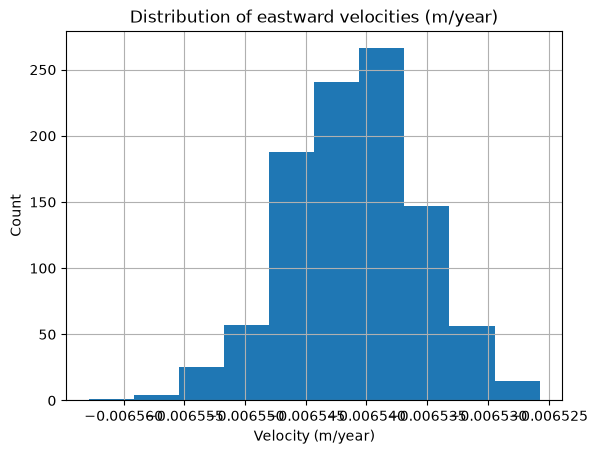

In [27]:
from sklearn.utils import resample

k = 1000
vel = np.zeros(k)  # initialize a vector to store the regression slopes
for i in range(k):
    ii = resample(np.arange(len(E)), replace=True, n_samples=len(E),
                  random_state=i)  # new indices
    E_b, t_b = E[ii], t[ii]
    # Fit the resampled data
    regr = LinearRegression()
    regr.fit(t_b, E_b)
    vel[i] = regr.coef_[0][0]

# The data shows a clear trend, so the slope estimates are close to each other:
print("mean of the velocity estimates %g m/yr and standard deviation %g m/yr"
      % (np.mean(vel), np.std(vel)))

plt.hist(vel, 10)
plt.title('Distribution of eastward velocities (m/year)')
plt.xlabel('Velocity (m/year)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

The bootstrap spread on the real data is small because the trend dominates the noise, just as it did for the synthetic case. The same caveat applies: GNSS noise is time-correlated, so treat this error bar as a lower bound.